In [2]:
### Company's 2014-2018 sales data to identify key revenue and profit drivers across products,channels and regions,uncover seasonal trends and outliers and align performance against budgets. Use these insights to optimize pricing, promotions and market expansion for sustainable growth and reduced concentration risk.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sheets = pd.read_excel(r'C:\Users\sadha\Desktop\AI DAP\Regional Sales Dataset.xlsx', sheet_name=None)

In [5]:
print(sheets.keys())

dict_keys(['Sales Orders', 'Customers', 'Regions', 'State Regions', 'Products', '2017 Budgets'])


In [6]:
df_sales = sheets['Sales Orders']  
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budget = sheets['2017 Budgets']

In [7]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [8]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [9]:
new_header = df_state_reg.iloc[0]
df_state_reg.columns = new_header
df_state_reg = df_state_reg[1:].reset_index(drop=True)

df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [10]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [11]:
df_budget.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [12]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [13]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [14]:
df_budget.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

In [15]:
#### **Data Cleaning and Preprocessing**


In [16]:
# Merge with Customers
df = df_sales.merge(
  df_customers,
  how='left',
  left_on='Customer Name Index',
  right_on='Customer Index'
)

In [17]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [18]:
# Merge with Products
df = df.merge(
  df_products,
  how='left',
  left_on='Product Description Index',
  right_on='Index'
)

In [19]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [20]:
# Merge with Regions
df = df.merge(
  df_regions,
  how='left',
  left_on='Delivery Region Index',
  right_on='id'
)

In [21]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [22]:
# Merge with Budget
df = df.merge(
  df_budget,
  how='left',
  on='Product Name'

)

In [23]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,1085037.329


In [24]:
#Customer Index
#Index
#id
#State Code

#Clean up redundant columns
cols_to_drop = ['Customer index','Index','id','State Code']

df= df.drop(columns =cols_to_drop,errors='ignore')

In [25]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,1085037.329


In [26]:
#convert column name to lower case
df.columns= df.columns.str.lower()

In [27]:
df.columns.values

<ArrowStringArray>
[              'ordernumber',                 'orderdate',
       'customer name index',                   'channel',
             'currency code',            'warehouse code',
     'delivery region index', 'product description index',
            'order quantity',                'unit price',
                'line total',           'total unit cost',
            'customer index',            'customer names',
              'product name',                      'name',
                    'county',                'state_code',
                     'state',                      'type',
                  'latitude',                 'longitude',
                 'area_code',                'population',
                'households',             'median_income',
                 'land_area',                'water_area',
                 'time_zone',              '2017 budgets']
Length: 30, dtype: str

In [28]:
# Keep the important columns and delete the columns that are not relevant for analysis


cols_to_keep = [
  'ordernumber',
  'orderdate',
  'customer names',
  'channel',
  'product name',
  'order quantity',
  'unit price',
  'line total',
  'total unit cost',
  'state_code',
  'county',
  'state',
  
  'latitude',
  'longitude',
  '2017 budgets'
]

In [29]:
df =df[cols_to_keep]

In [30]:
df.head(5)

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,41.77524,-72.52443,1085037.329


In [31]:
# Rename columns for better readability
df = df.rename(columns={
  'ordernumber': 'order_number',
  'orderdate': 'order_date',
  'customer names': 'customer_name',
  'product name': 'product_name',
  'order quantity': 'order_quantity',
  'unit price': 'unit_price',
  'line total': 'revenue',
  'total_unit cost': 'cost',
  'state_code':'state',
  'state':'state_name',
  'latitude':'lat',
  'longitude':'lon',
  '2017 budgets':'budget'

})

In [32]:
# blank out budgets for non 2017 orders
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

#  line total is revenue
df[['order_date','product_name','revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [33]:
#  line total is revenue
df[['order_date','product_name','revenue','budget']].tail(5)

,order_date,product_name,revenue,budget
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN
64103,2018-02-28,Product 15,7986.4,NaN


In [34]:
# Filter data for the year 2017

df_2017 = df[df['order_date'].dt.year == 2017]

In [35]:
df.isnull().sum()

order_number           0
order_date             0
customer_name          0
channel                0
product_name           0
order_quantity         0
unit_price             0
revenue                0
total unit cost        0
state                  0
county                 0
state_name             0
lat                    0
lon                    0
budget             48841
dtype: int64

In [36]:
df_2017.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,28.47689,-82.52546,3050087.565


In [ ]:
Feature engineering - create new features like profit, profit margin, month, quarter, year etc.

In [41]:
df['total_cost']= df['order_quantity'] * df['total unit cost']

In [42]:
df['profit'] = df['revenue'] - df['total_cost']

In [43]:
df['profit_margin_pct'] = df['profit'] / df['revenue']* 100

In [44]:
df.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,lat,lon,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


In [ ]:
#### EDA


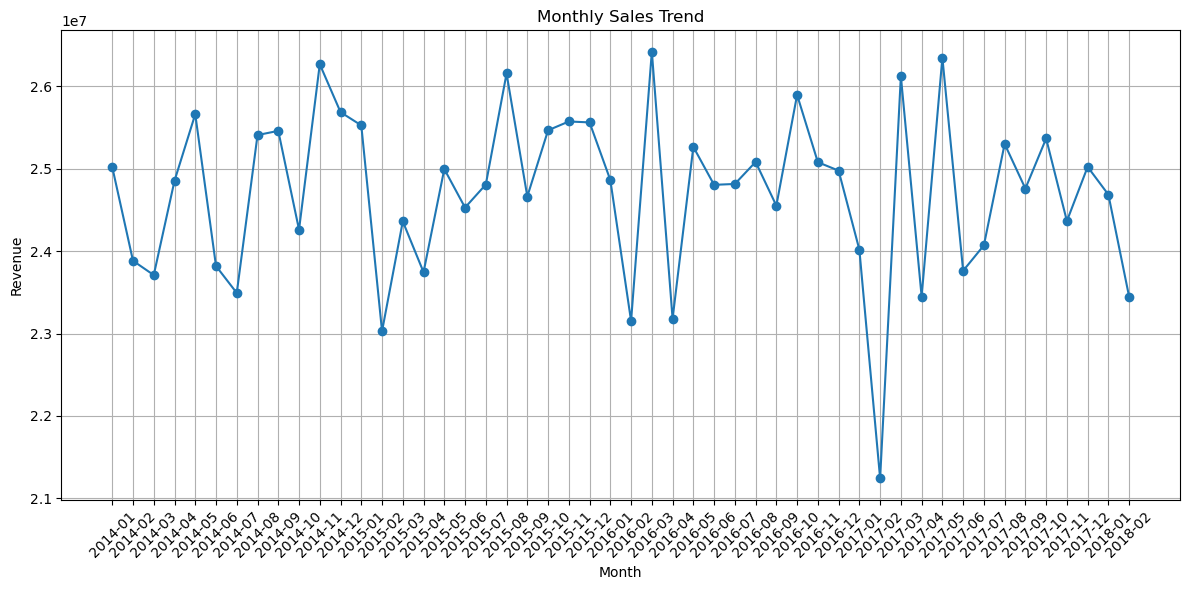

In [46]:


# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Create monthly sales summary
monthly_sales = (
    df.groupby(df['order_date'].dt.to_period('M'))['revenue']
      .sum()
      .reset_index()
)

# Convert Period to string for plotting
monthly_sales['order_date'] = monthly_sales['order_date'].astype(str)

# Plot monthly sales trend
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales['order_date'],
    monthly_sales['revenue'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

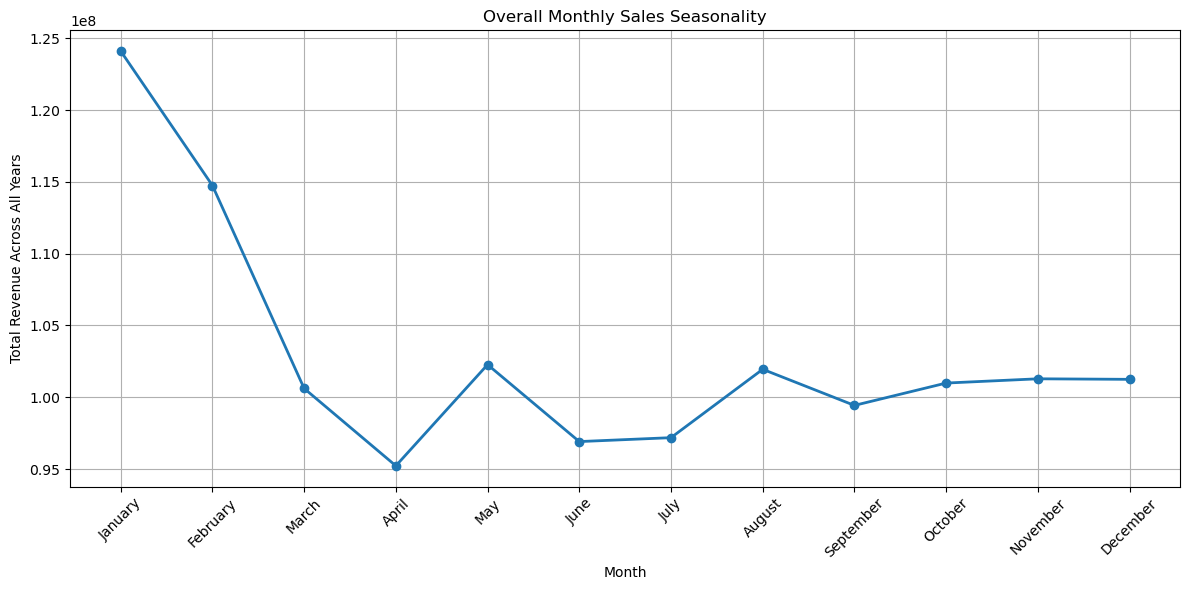

In [47]:


# Convert date column to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract month name
df['month'] = df['order_date'].dt.month_name()

# Define correct month order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Aggregate revenue by calendar month
monthly_seasonality = (
    df.groupby('month')['revenue']
      .sum()
      .reindex(month_order)
      .reset_index()
)

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    monthly_seasonality['month'],
    monthly_seasonality['revenue'],
    marker='o',
    linewidth=2
)

plt.title('Overall Monthly Sales Seasonality')
plt.xlabel('Month')
plt.ylabel('Total Revenue Across All Years')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [48]:
# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Remove 2018-01 and 2018-02 records
df = df[
    ~(
        ((df['order_date'].dt.year == 2018) & (df['order_date'].dt.month == 1)) |
        ((df['order_date'].dt.year == 2018) & (df['order_date'].dt.month == 2))
    )
]

# Reset index (optional)
df = df.reset_index(drop=True)

In [49]:
df.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,lat,lon,budget,total_cost,profit,profit_margin_pct,month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January


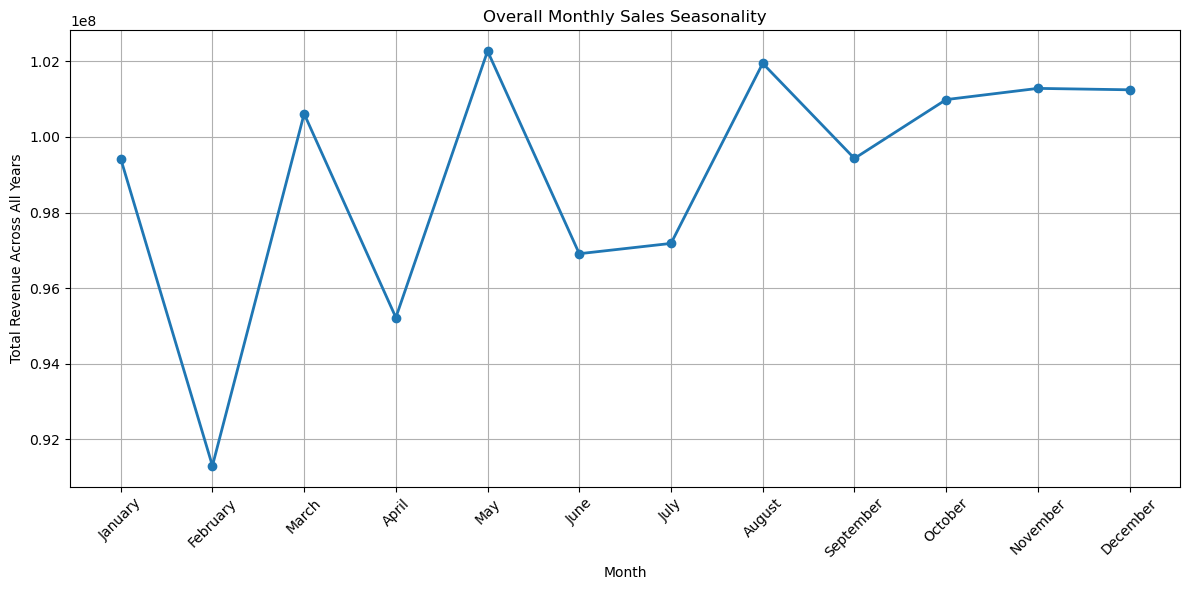

In [50]:


# Convert date column to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extract month name
df['month'] = df['order_date'].dt.month_name()

# Define correct month order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Aggregate revenue by calendar month
monthly_seasonality = (
    df.groupby('month')['revenue']
      .sum()
      .reindex(month_order)
      .reset_index()
)

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    monthly_seasonality['month'],
    monthly_seasonality['revenue'],
    marker='o',
    linewidth=2
)

plt.title('Overall Monthly Sales Seasonality')
plt.xlabel('Month')
plt.ylabel('Total Revenue Across All Years')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

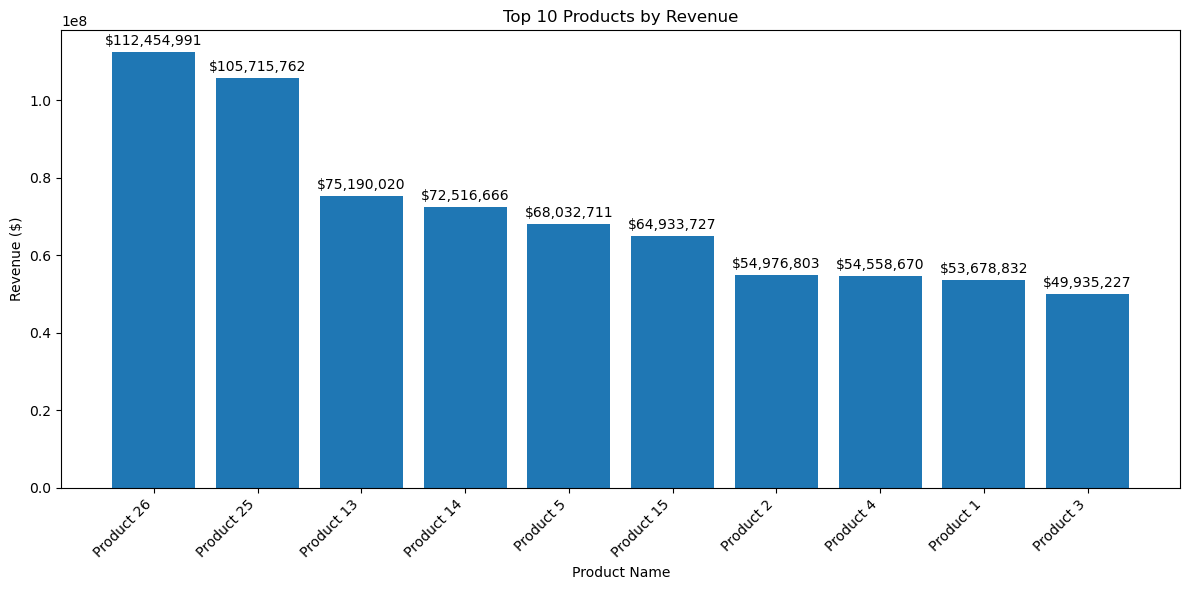

In [53]:
import matplotlib.pyplot as plt

top_products = (
    df.groupby('product_name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top_products['product_name'],
    top_products['revenue']
)

# Dollar labels
plt.bar_label(
    bars,
    labels=[f'${x:,.0f}' for x in top_products['revenue']],
    padding=3
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

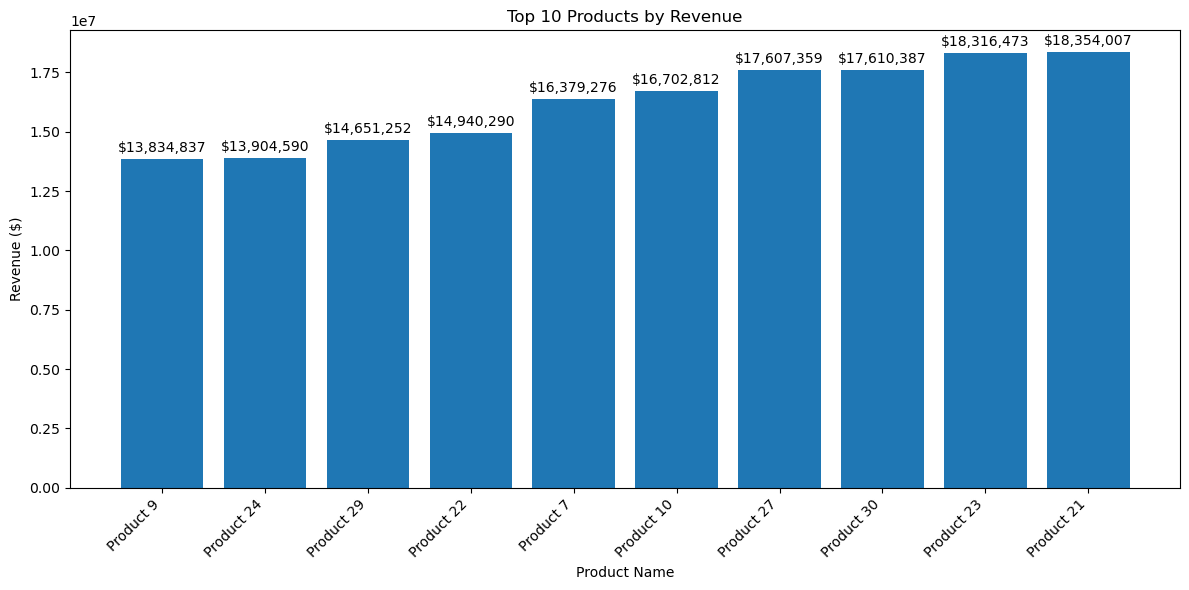

In [54]:
import matplotlib.pyplot as plt

top_products = (
    df.groupby('product_name')['revenue']
      .sum()
      .sort_values(ascending=True)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top_products['product_name'],
    top_products['revenue']
)

# Dollar labels
plt.bar_label(
    bars,
    labels=[f'${x:,.0f}' for x in top_products['revenue']],
    padding=3
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

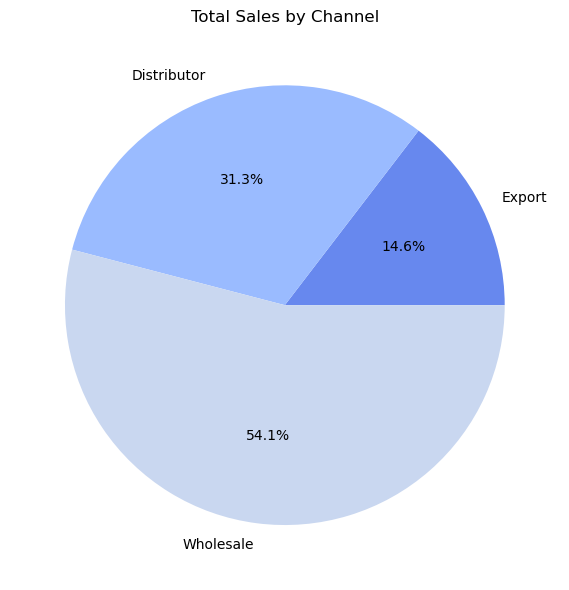

In [57]:
# Sales by Channel

chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(8,6))

plt.pie(
  chan_sales.values,
  labels=chan_sales.index,
  autopct='%1.1f%%',
  colors=sns.color_palette('coolwarm')
)
plt.title('Total Sales by Channel')
plt.tight_layout()
plt.show()

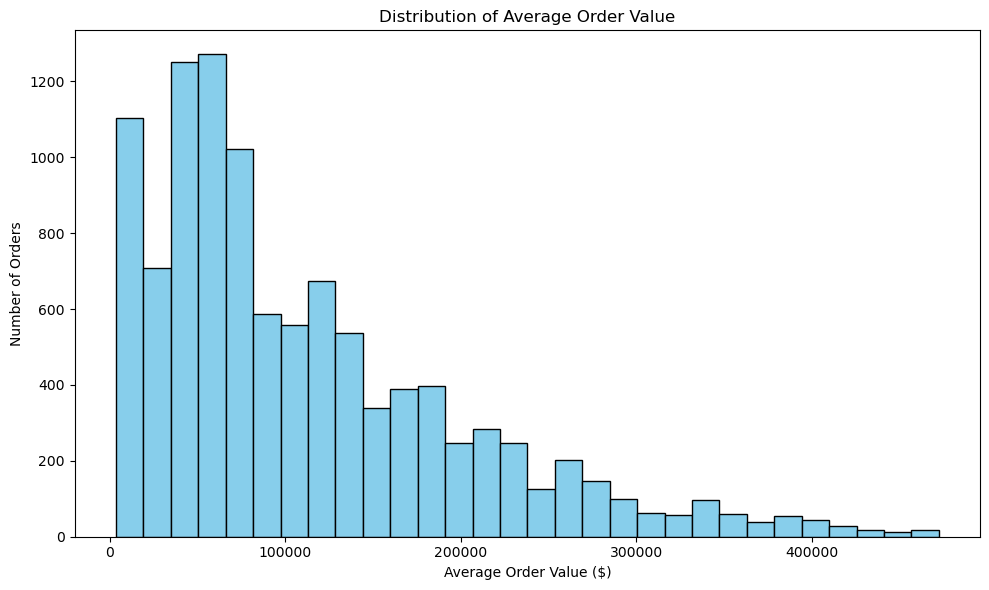

In [58]:
## Average Order Value Distribution

aov = df.groupby('order_number')['revenue'].sum()
plt.figure(figsize=(10,6))
plt.hist(aov, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Average Order Value')
plt.xlabel('Average Order Value ($)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

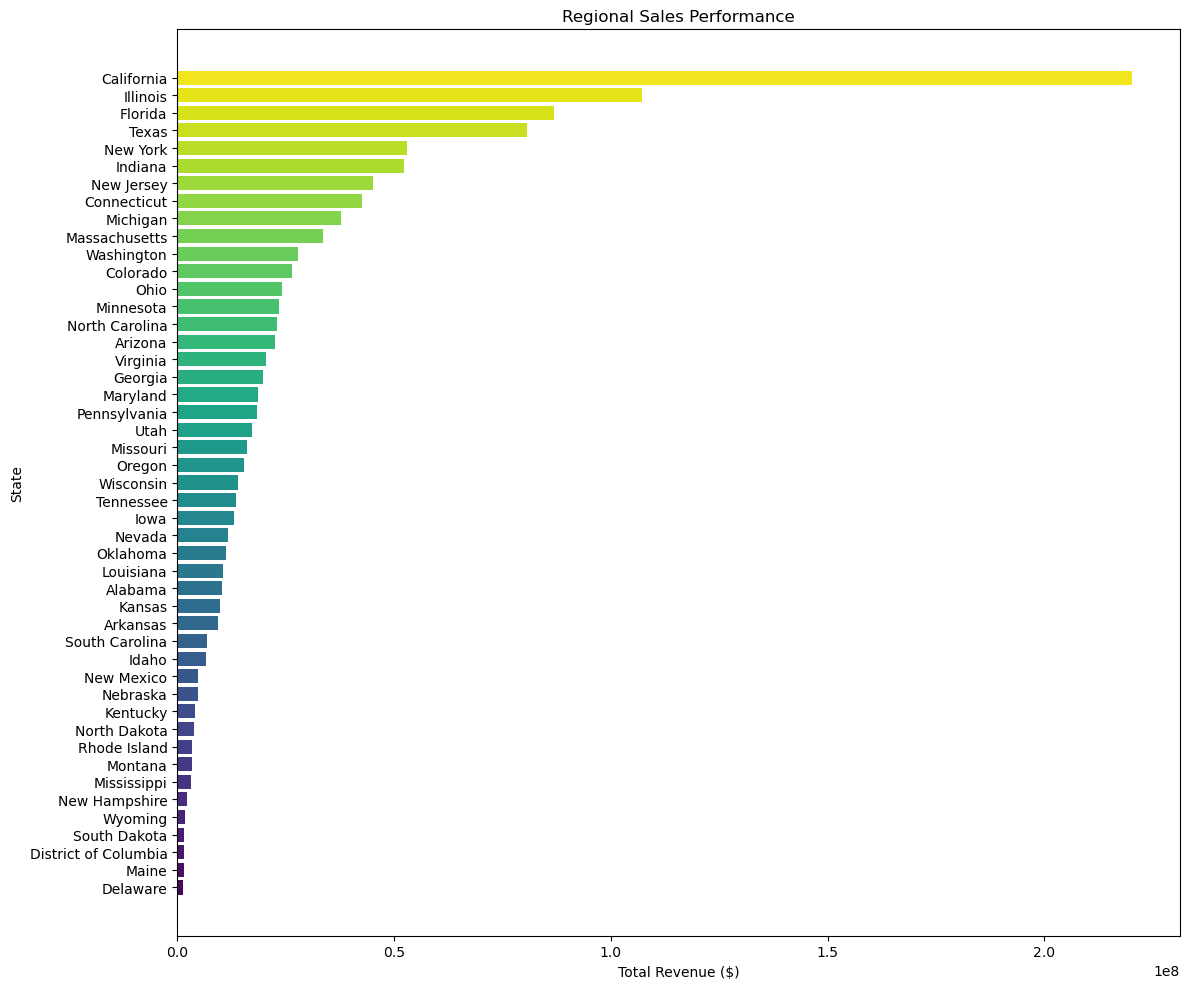

In [62]:
 ## Regional Sales Performance

reg_sales = df.groupby('state_name')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(12,10))
plt.barh(
    reg_sales.index,
    reg_sales.values,
    color=sns.color_palette('viridis', len(reg_sales))
)
plt.title('Regional Sales Performance')
plt.xlabel('Total Revenue ($)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

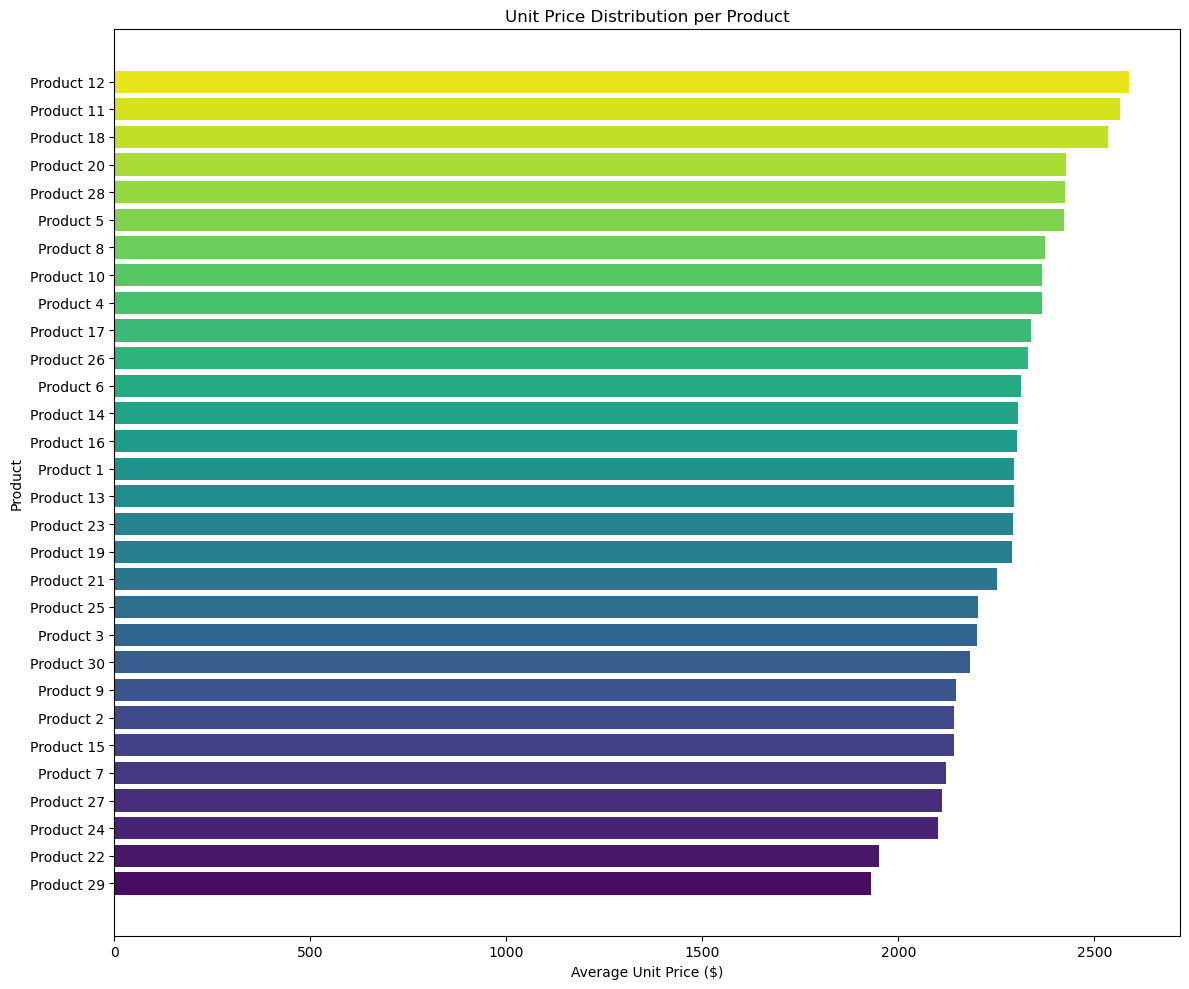

In [66]:
## Unit Price Distribution per Product

UPD = df.groupby('product_name')['unit_price'].mean().sort_values(ascending=True)

plt.figure(figsize=(12,10))
plt.barh(
    UPD.index,
    UPD.values,
    color=sns.color_palette('viridis', len(UPD))
)
plt.title('Unit Price Distribution per Product')
plt.xlabel('Average Unit Price ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


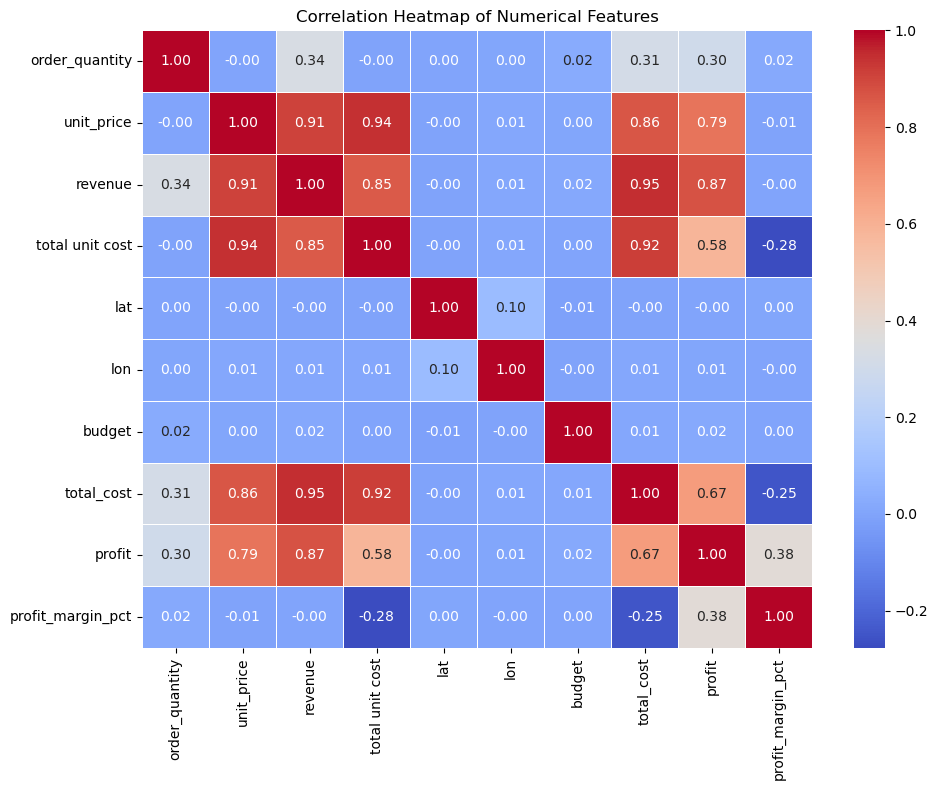

In [67]:
## Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number])  
plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

c:\Users\sadha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


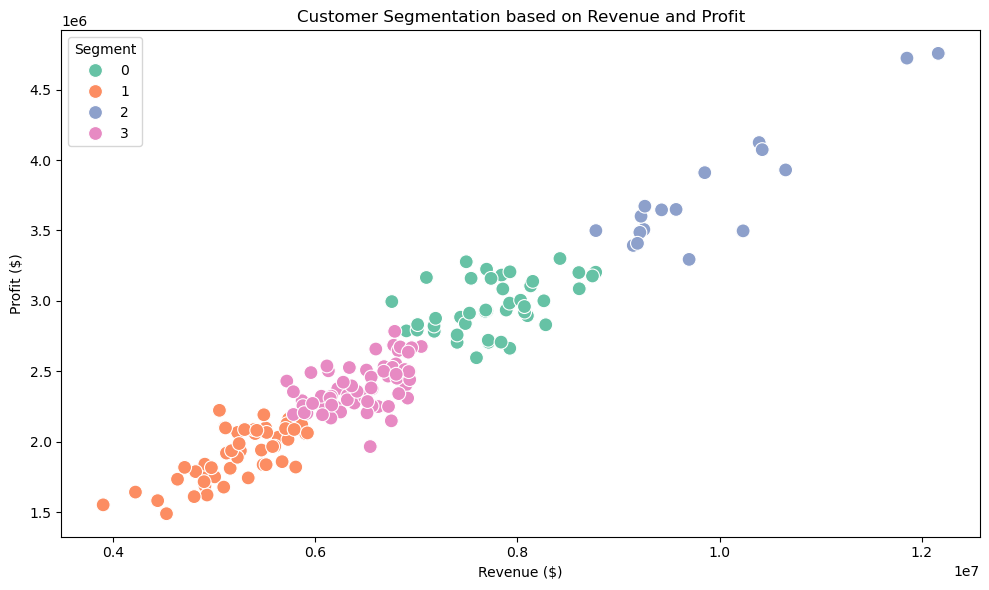

In [70]:


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Aggregate customer metrics
customer_data = (
    df.groupby('customer_name')
      .agg({
          'revenue': 'sum',
          'profit': 'sum'
      })
      .reset_index()
)

# Features for clustering
features = customer_data[['revenue', 'profit']]

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# KMeans clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data['customer_segment'] = kmeans.fit_predict(scaled_features)

# Visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_data,
    x='revenue',
    y='profit',
    hue='customer_segment',
    palette='Set2',
    s=100
)

plt.title('Customer Segmentation based on Revenue and Profit')
plt.xlabel('Revenue ($)')
plt.ylabel('Profit ($)')
plt.legend(title='Segment')

plt.tight_layout()
plt.show()